#  Python: Plotting maps with Cartopy
## Chapter 13 from the Alex DeCaria textbook

<br>
<img src='../images/cartopy_logo.png' width=800px align='center' style='padding-left:50px'>
<br>

> # Today's Objective<br>
> Review map plotting basics with Cartopy<br>
> Ajust map projections<br>
> Adding points, images, and background data to Cartopy maps<br>
> Overlaying color-filled contours and vectors to a map<br>
> Practice plotting "real" weather data<br>
<br><br>
In addition to todays lecture, it is *highly* recommended that you review **Chapter 13** of the DeCaria text
<br><br>
Before starting: Make sure that you open up a Jupyter notebook session using OnDemand so you can interactively follow along with today's lecture!
<br><br>
Today's juypter notebook lecture can be copied from my Atmos 5340 directory on CHPC:<br><br>
*/uufs/chpc.utah.edu/common/home/u0703457/atmos_5340/module12/*
<br>
<br>

# What is Cartopy?
Cartopy is a Python package designed to make drawing maps for data analysis and visualisation easy. The Cartopy package is the successor of the "Basemaps" package, which was retired in 2022 and was Python original map plotting library. Cartopy is an essential tool for Atmospheric Scientists who want to plot spatial weather data. Cartopy features:
- Object oriented projection definitions
- Point, line, polygon and image transformations between projections
- Integration to expose advanced mapping in Matplotlib with a simple and intuitive interface. 
<br>


Here is an example of what is possible with Cartopy:

<br>
<img src='../images/figure4e.png' width=800px align='center' style='padding-left:50px'>
<br>
Here, you can see that we simultaneously overlaid a contour map and color-filled points on map of the Western U.S.
<br><br>
Cartopy has exposed an interface to enable easy map creation using matplotlib. Creating a basic map is as simple as telling matplotlib to use a specific map projection, and then adding some coastlines to the axes:

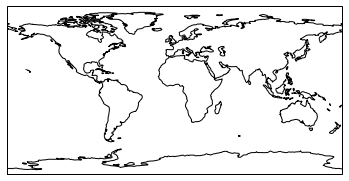

In [3]:
from cartopy import crs as ccrs, feature as cfeature

import matplotlib.pyplot as plt

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

Here, we import the main libraries of Cartopy: crs and feature. In addition, we import numpy, as well as matplotlib’s pyplot interface.<br>
<br>
We can plot this same map, using a different projection. For example:

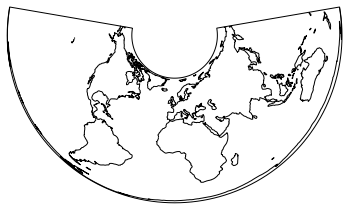

In [4]:
ax = plt.axes(projection=ccrs.AlbersEqualArea())
ax.coastlines()

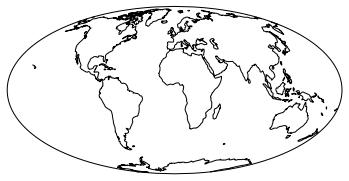

In [5]:
ax = plt.axes(projection=ccrs.Mollweide())
ax.coastlines()

A full list of projections that can be handled by Cartopy can be viewed here:
https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html#cartopy-projections
<br><br>
## But what are we really doing?

Since we imported cartopy.crs, we now have access to Cartopy’s Coordinate Reference System, which contains many geographical projections. We can specify one of these projections for an Axes object to convert it into a GeoAxes object. This will effectively georeference the subplot. Examples of converting Axes objects into GeoAxes objects can be found later in this section.
<br><br>
Lets step through an example to make sense of what we are doing... Here, we will first create a GeoAxes object that uses the PlateCarree projection. PlateCarree is a global lat-lon map projection in which each point is evenly spaced in terms of degrees. The name “Plate Carree” is French for “flat square”.

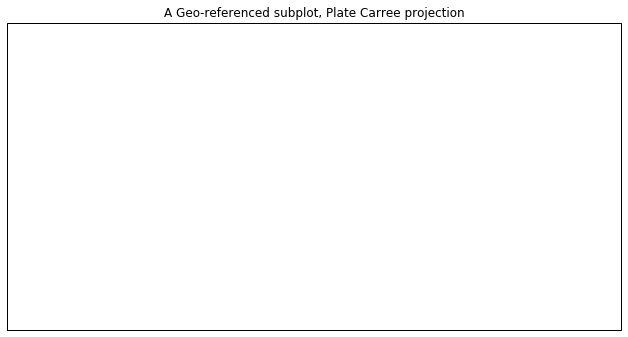

In [20]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=-75))
ax.set_title("A Geo-referenced subplot, Plate Carree projection");

While this figure "looks" empty, this plot is actually georeferenced using a map projection. This projection is provided by Cartopy’s `crs` (coordinate reference system) class. We can now add in cartographic features, in the form of shapefiles, to our subplot. One such cartographic feature is coastlines, which can be added to our subplot using the callable `GeoAxes` method simply called `coastlines`.

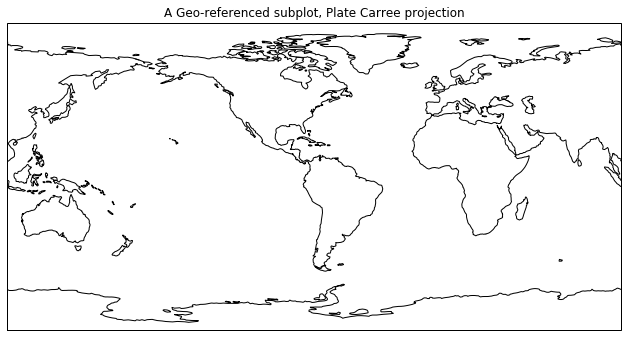

In [22]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=-75))
ax.set_title("A Geo-referenced subplot, Plate Carree projection");
ax.coastlines()

## Add cartographic features to the map

Cartopy provides other cartographic features via its features class, which was imported at the beginning of this page, under the name cfeature. These cartographic features are laid out as data in shapefiles. The shapefiles are downloaded when their cartographic features are used for the first time in a script or notebook, and they are downloaded from https://www.naturalearthdata.com/. Once downloaded, they “live” in your `~/.local/share/cartopy` directory (note the ~ represents your home directory).
<br>
<br>
We can add these features to our subplot via the add_feature method; this method allows the definition of attributes using arguments, similar to Matplotlib’s plot method. A list of the various Natural Earth shapefiles can be found at https://scitools.org.uk/cartopy/docs/latest/matplotlib/feature_interface.html.
<br><br>
In the example below, we add borders and U.S state lines to our subplot:

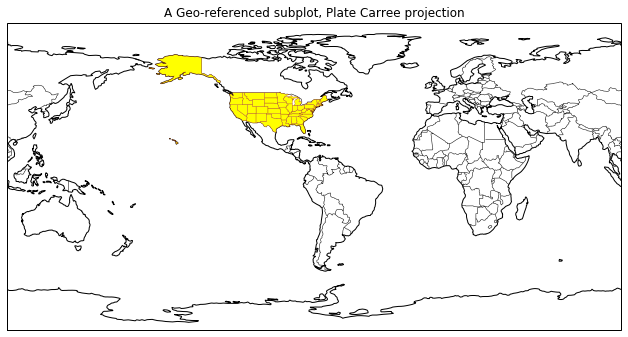

In [27]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=-75))
ax.set_title("A Geo-referenced subplot, Plate Carree projection");
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=.5, edgecolor='black')
ax.add_feature(cfeature.STATES, facecolor='yellow', linewidth=0.3, edgecolor='brown')

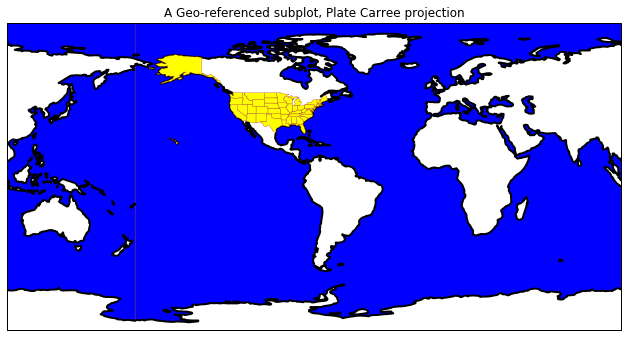

In [33]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=-75))
ax.set_title("A Geo-referenced subplot, Plate Carree projection");
ax.coastlines(linewidth=2)
ax.add_feature(cfeature.STATES, facecolor='yellow', linewidth=0.3, edgecolor='brown')
ax.add_feature(cfeature.OCEAN, facecolor='blue', linewidth=0.3, edgecolor='brown')

Lets make a Mollweide projection map as another example.

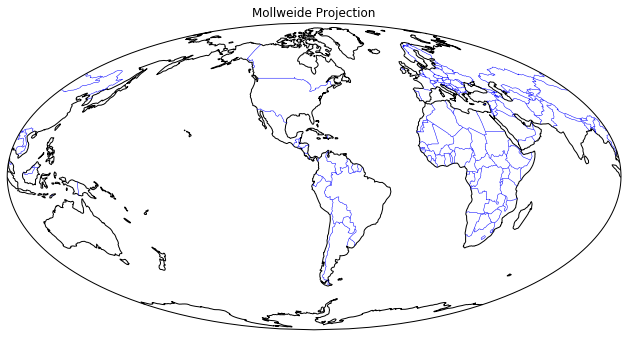

In [34]:
fig = plt.figure(figsize=(11, 8.5))
projMoll = ccrs.Mollweide(central_longitude=-80)
ax = plt.subplot(1, 1, 1, projection=projMoll)
ax.set_title("Mollweide Projection")
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='blue')

We can also add an image in the background via the `stock_img` method 

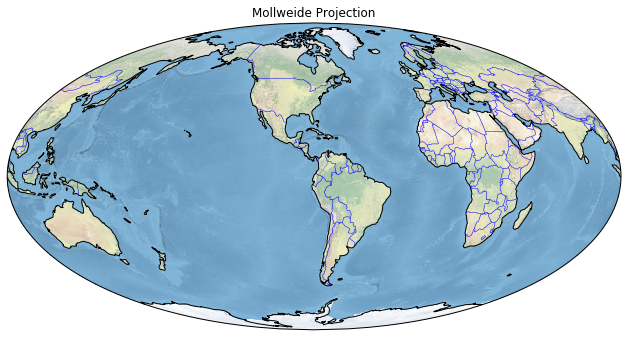

In [8]:
fig = plt.figure(figsize=(11, 8.5))
projMoll = ccrs.Mollweide(central_longitude=-80)
ax = plt.subplot(1, 1, 1, projection=projMoll)
ax.set_title("Mollweide Projection")
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='blue')
ax.stock_img()

# Creating regional maps

Global maps are great, but what if we want to display data on the regional scale? Here, we will use Cartopy’s set_extent method to restrict the map coverage to a North American view. Let’s also choose a lower resolution for coastlines, just to illustrate how one can specify that. In addition, let’s also plot the latitude and longitude lines.
<br><br>
Natural Earth defines three resolutions for cartographic features, specified as the strings “10m”, “50m”, and “110m”. Only one resolution can be used at a time, and the higher the number, the less detailed the feature becomes. You can view the documentation for this functionality at the following reference link: https://www.naturalearthdata.com/downloads/

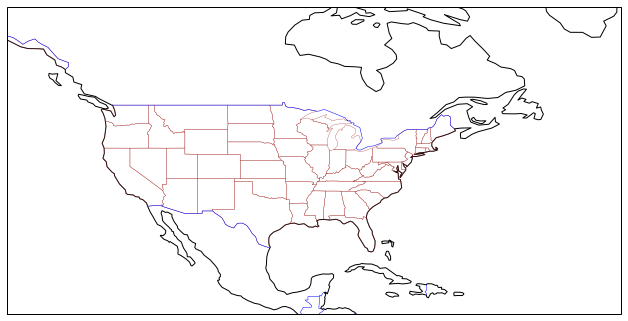

In [38]:
projPC = ccrs.PlateCarree()
lonW = -140
lonE = -40
latS = 15
latN = 65
cLat = (latN + latS) / 2
cLon = (lonW + lonE) / 2
res = '110m'

fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=projPC)
ax.set_extent([lonW, lonE, latS, latN], crs=projPC)
ax.coastlines(resolution=res, color='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='blue')


To add grid lines, you can call the `gridlines` method:

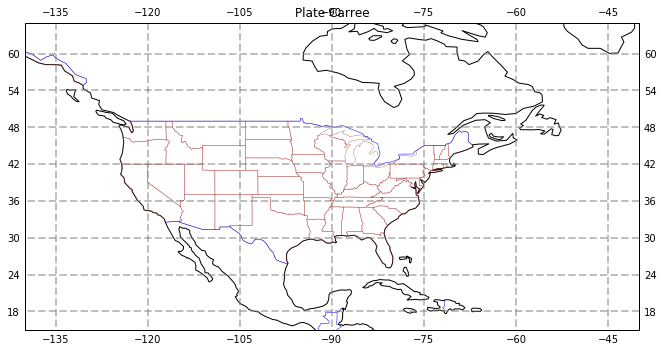

In [46]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=projPC)
ax.set_title('Plate Carree')
gl = ax.gridlines(draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')
ax.set_extent([lonW, lonE, latS, latN], crs=projPC)
ax.coastlines(resolution=res, color='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='blue')

**Note** Lat/lon labeling for projections other than Mercator and PlateCarree is a recent addition to Cartopy. As you can see, work still needs to be done to improve the placement of labels. It is also worth noting that this feature may not work for all projections.
<br><br>

Lets really zoom in...

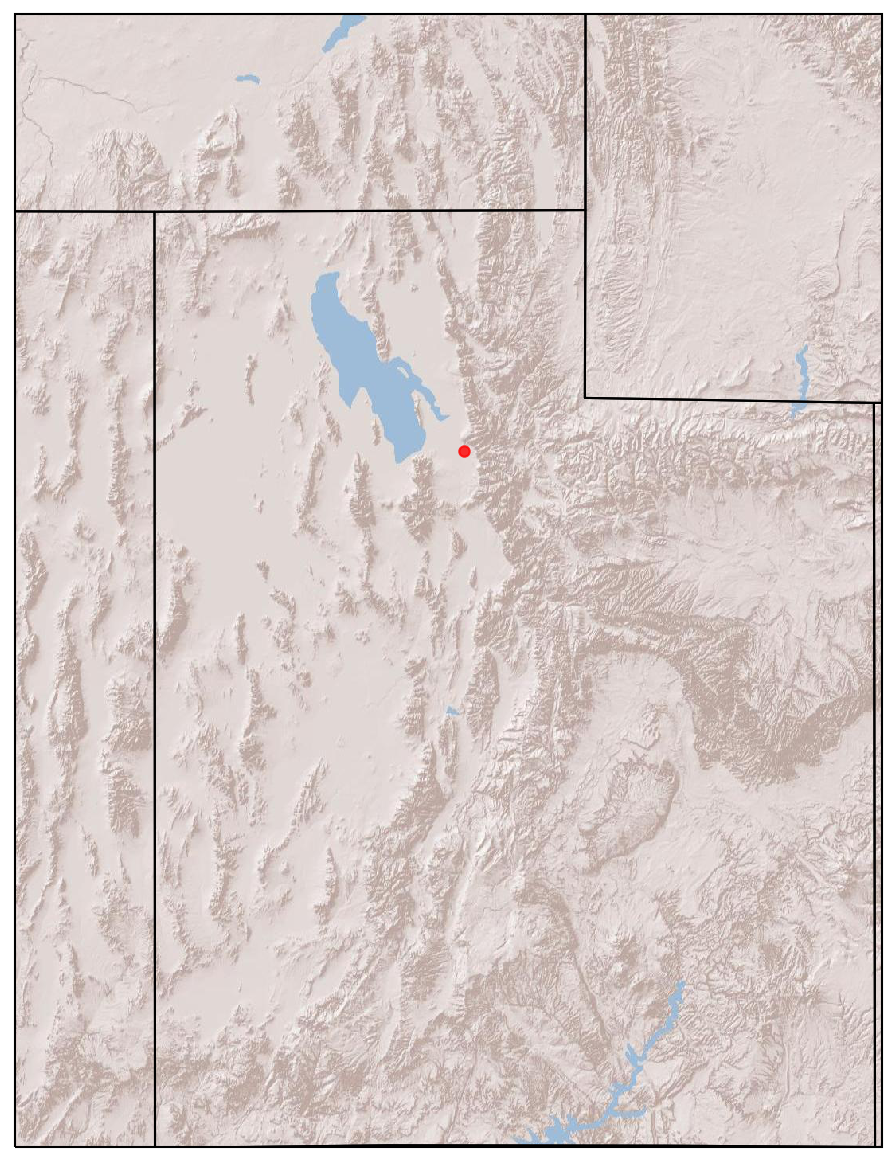

In [58]:
#Lets plot up all of our observations on a Google map tile.
from cartopy.io.img_tiles import GoogleTiles

#Create a plot 
fig = plt.figure(figsize = (10, 10),dpi=150)

#Download the image file from server
tiler = GoogleTiles(style='street',url='https://server.arcgisonline.com/ArcGIS/rest/services/World_Shaded_Relief/MapServer/tile/{z}/{y}/{x}.jpg')

#Set up plot, plot extent, boundaries, and how zoomed in we want our image to be (more zoomed out makes image file look "fuzzy".
ax = plt.axes(projection=tiler.crs)
ax.set_extent([-115, -109, 37, 43], crs=ccrs.Geodetic())
ax.add_feature(cfeature.STATES)
zoom = 8
ax.add_image(tiler, zoom)

# Add a marker and create plot
home_lat, home_lon = 40.75,-111.89
plt.plot(home_lon, home_lat, marker='o', color='red', markersize=5,alpha=0.8,transform=ccrs.Geodetic())
plt.show()

# Plotting data on a map

First, we’ll create a lat-lon grid and define some data on it.

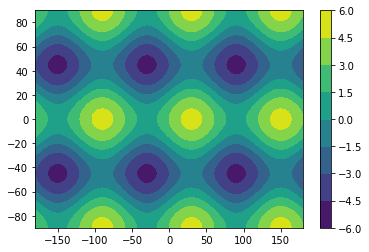

In [59]:
import numpy as np 

lon, lat = np.mgrid[-180:181, -90:91]
data = 2 * np.sin(3 * np.deg2rad(lon)) + 3 * np.cos(4 * np.deg2rad(lat))
plt.contourf(lon, lat, data)
plt.colorbar()

Plotting data on a Cartesian grid is equivalent to plotting data in the PlateCarree projection, where meridians and parallels are all straight lines with constant spacing. As a result of this simplicity, the global datasets we use often begin in the PlateCarree projection.
<br><br>
Once we create our map again, we can plot these data values as a contour map. We must also specify the `transform` keyword argument. This is an argument to a contour-plotting method that specifies the projection type currently used by our data. The projection type specified by this argument will be transformed into the projection type specified in the `axes` method. Let’s plot our data in the Mollweide projection to see how shapes change under a transformation.

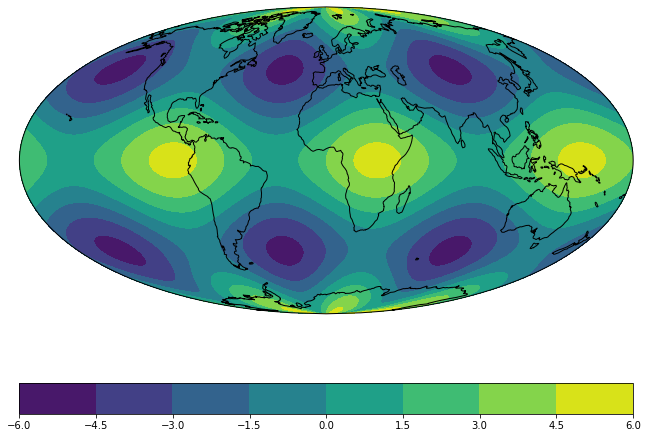

In [60]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.axes(projection=ccrs.Mollweide())
ax.coastlines()
dataplot = ax.contourf(lon, lat, data, transform=ccrs.PlateCarree())
plt.colorbar(dataplot, orientation='horizontal')

## Another example

Lets try to plot some real data now. In this case, SSTs

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    Conventions: CF-1.0
    title: Monthly version of HadISST sea surface temperature component
    institution: Met Office, Hadley Centre for Climate Research
    source: HadISST
    history: 09/11/2006 HadISST converted to NetCDF from pp format by John Kennedy
    references: Rayner, N. A., Parker, D. E., Horton, E. B., Folland, C. K., Alexander, L. V., Rowell, D. P., Kent, E. C., Kaplan, A.  Global analyses of sea surface temperature, sea ice, and night marine air temperature since the late nineteenth century J. Geophys. Res.Vol. 108, No. D14, 4407 10.1029/2002JD002670
    comment: Data restrictions: for academic research use only. Data are Crown copyright see (http://www.opsi.gov.uk/advice/crown-copyright/copyright-guidance/index.htm)
    supplementary_information: Updates and supplementary information will be available from http://www.hadobs.org
    contact: john.kennedy@metoffice.gov.

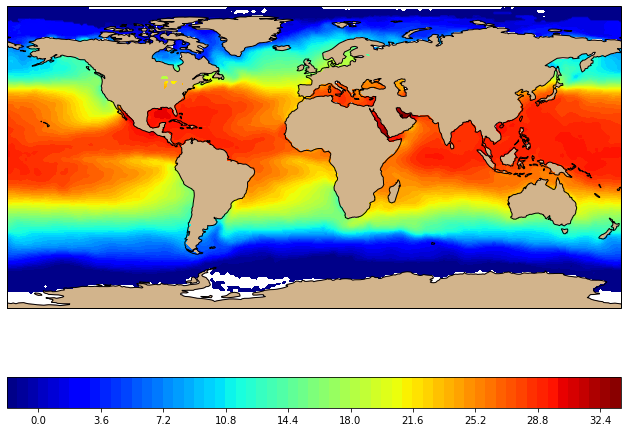

In [62]:
import os
import matplotlib.pyplot as plt
from netCDF4 import Dataset as netcdf_dataset
import numpy as np
from cartopy import config
import cartopy.crs as ccrs


#Get the path of the file. It can be found in the repo data directory.
fname = os.path.join(config["repo_data_dir"],'netcdf', 'HadISST1_SST_update.nc')

#Read in the SST data, including the lat lons since we need to georeference that
dataset = netcdf_dataset(fname)
print(dataset)
sst = dataset.variables['sst'][0, :, :]
lats = dataset.variables['lat'][:]
lons = dataset.variables['lon'][:]

#Lets set some map plotting parameters and then plot everything up on a contour map
cmap = plt.cm.jet       
fig = plt.figure(figsize=(11, 8.5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='tan', linewidth=0.3, edgecolor='brown')

sst_contour = plt.contourf(lons, lats, sst, 60,cmap=cmap,transform=ccrs.PlateCarree())

plt.colorbar(sst_contour, orientation='horizontal')
ax.coastlines()

What if we wanted to add a point to our map?


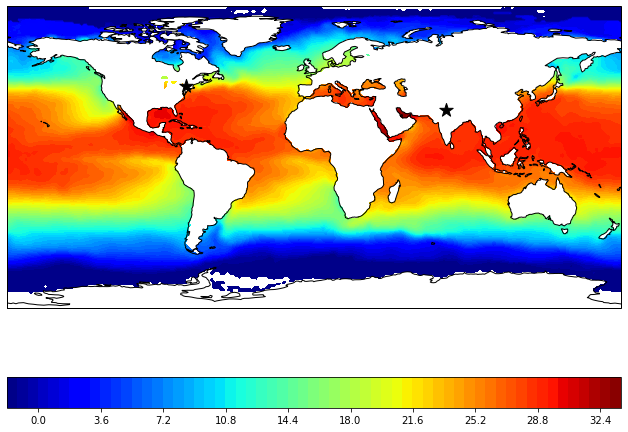

In [15]:
#Lets set some map plotting parameters and then plot everything up on a contour map
cmap = plt.cm.jet       
fig = plt.figure(figsize=(11, 8.5))
ax = plt.axes(projection=ccrs.PlateCarree())

sst_contour = plt.contourf(lons, lats, sst, 60,cmap=cmap,transform=ccrs.PlateCarree())

#Add two markers to our map
ny_lon, ny_lat = -75, 43
delhi_lon, delhi_lat = 77.23, 28.61
plt.scatter([ny_lon, delhi_lon], [ny_lat, delhi_lat],color='black', marker='*',s=200,transform=ccrs.PlateCarree())

plt.colorbar(sst_contour, orientation='horizontal')
ax.coastlines()

What if we wanted to zoom in our a region?

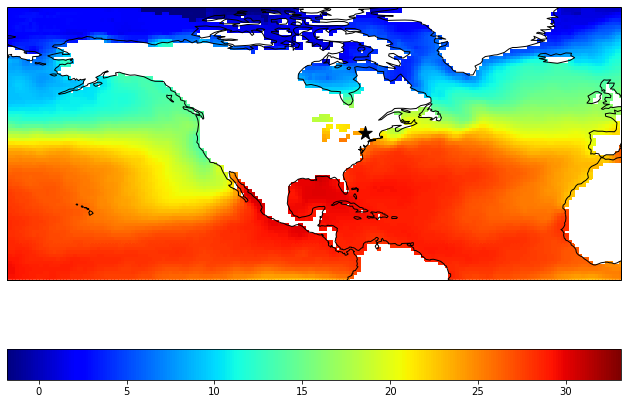

In [66]:
#Lets set some map plotting parameters and then plot everything up on a contour map
cmap = plt.cm.jet       
fig = plt.figure(figsize=(11, 8.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 0, 0, 80], crs=ccrs.PlateCarree())

sst_contour = plt.pcolormesh(lons, lats, sst,cmap=cmap,transform=ccrs.PlateCarree())

#Add two markers to our map
ny_lon, ny_lat = -75, 43
delhi_lon, delhi_lat = 77.23, 28.61
plt.scatter([ny_lon, delhi_lon], [ny_lat, delhi_lat],color='black', marker='*',s=200,transform=ccrs.PlateCarree())

plt.colorbar(sst_contour, orientation='horizontal')
ax.coastlines()

# Working with GRIB data

Next, lets try plotting some data from the GFS model and overlay some weather data! First, lets grab some data from the GFS weather model. Since opertional weather model data is typically stored in the GRIB data format, there are some hoops we need to jump through to get this in a format that is easy to work with. A GRIB (GRIdded Binary) file format is a widely used standard for encoding and distributing meteorological and oceanographic data. It is a binary data format that is specifically designed for representing gridded data, such as weather forecasts, climate model outputs, and other geospatial datasets. GRIB files are commonly used in the fields of meteorology, atmospheric science, and environmental research.
<br><br>
GRIB files offer several advantages for storing and sharing gridded data:
<br><br>
**Efficiency:** GRIB files are binary, which means they are compact and efficient for storing large volumes of numerical data.
<br><br>
**Self-Describing:** GRIB files include metadata that describe the content and structure of the data, making them self-describing and facilitating interoperability between different software and systems.
<br><br>
**Data Compression:** GRIB files often employ data compression techniques to reduce file sizes while maintaining the accuracy of the data.
<br><br>
**Grid-agnostic:** GRIB files can represent various types of grids, such as latitude-longitude, polar stereographic, and other specialized grids used in meteorology and oceanography.
<br><br>
**Multi-Dimensional Data:** GRIB files support multi-dimensional data structures, enabling storage of data across time, vertical levels, and geographic locations.
<br><br>
GRIB files are typically produced and consumed by meteorological and oceanographic modeling systems, satellite data processing tools, weather forecasting centers, and scientific research applications. There are different versions of the GRIB format (GRIB1 and GRIB2) with varying levels of complexity and capabilities. The choice of format depends on the specific needs of the data and the applications that use it.
<br><br>
To work with GRIB files, specialized software libraries and tools are often used to read, write, manipulate, and visualize the data. Popular libraries for handling GRIB files include the ECMWF GRIB API and the Python packages `pygrib` and `pynio`. These packages can be interfaced with xarray. 
<br><br>
<br><br>
`xarray` is a powerful open-source Python library designed to facilitate working with labeled multi-dimensional arrays (also known as "DataArrays") and labeled multi-dimensional datasets (also known as "Datasets"). It provides a convenient and efficient way to handle and analyze complex scientific data, particularly data from fields such as atmospheric and oceanic sciences, climatology, remote sensing, and geospatial analysis. Some key features and benefits of xarray include:
<br><br>
**Labeled Data:** xarray adds labels to multi-dimensional arrays and datasets, allowing you to associate metadata, coordinates, and dimension names with your data. This makes the data more self-descriptive and easier to work with.
<br><br>
**Alignment:** xarray automatically aligns arrays based on their coordinates, making it simpler to perform mathematical operations on arrays with different dimensions but compatible coordinates.
<br><br>
**Broadcasting:** The library supports broadcasting operations, allowing you to perform element-wise computations across arrays of different shapes.
I/O Handling: xarray can read and write data from/to various file formats, including NetCDF, GRIB, HDF5, and more. It simplifies loading and saving data, preserving metadata and coordinate information.
<br><br>
**Data Analysis:** xarray provides a range of built-in functions for data analysis, including aggregation, grouping, resampling, and interpolation.
<br><br>
**Indexing and Selection:** xarray offers flexible and expressive indexing and selection capabilities, allowing you to slice, mask, and filter data based on coordinates and labels.
<br><br>
To keep things simple, we will simply use `xarray` to read in our `GRIB1/2` data, and then convert it over to a `numpy array`. The code below will read in GFS weather data for us using xarray+pynio as the engine:

In [72]:
import xarray as xr
import numpy as np 

#Open up our grib file using xarray, using pynio as an engine
grib_path = "/uufs/chpc.utah.edu/common/home/u0703457/lin-group18/dvm/projects/atmos5340_files/data/gfs/0.25_degree/"
grib_data = xr.open_dataset(grib_path+"gfs.t00z.pgrb2.0p25.f000", engine="pynio")

#Read in geopotential heights, wind, and absolute vorticity on a constant pressure surface, and MSLP. 
gphgt_var = grib_data.get("HGT_P0_L100_GLL0")         #Geopotential height [m]
avort_var = grib_data.get("ABSV_P0_L100_GLL0")        #Absolute vorticity [s]
uwind_var = grib_data.get("UGRD_P0_L103_GLL0")        #U-wind component [m/s]
vwind_var = grib_data.get("VGRD_P0_L103_GLL0")        #V-wind component [m/s]
press_var = grib_data.get("PRMSL_P0_L101_GLL0")       #Mean-sea level pressure [mb]
rainr_var = grib_data.get("RWMR_P0_L105_GLL0")        #Rain mixing ratio [kg/kg]
temp2_var = grib_data.get("TMP_P0_L103_GLL0")         #Near-surface temperature [K]
prwat_var = grib_data.get("PWAT_P0_L200_GLL0")        #Precipitable water [kg m-2]


#Print out the contents of the grib file and the variables that we read in.
#print(grib_data)
print(gphgt_var)
print(avort_var)
print(uwind_var)
print(vwind_var)
print(press_var)
print(rainr_var)
print(temp2_var)
print(prwat_var)

<xarray.DataArray 'HGT_P0_L100_GLL0' (lv_ISBL0: 41, lat_0: 721, lon_0: 1440)>
[42567840 values with dtype=float32]
Coordinates:
  * lv_ISBL0  (lv_ISBL0) float32 1.0 2.0 4.0 7.0 ... 95000.0 97500.0 100000.0
  * lat_0     (lat_0) float32 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon_0     (lon_0) float32 0.0 0.25 0.5 0.75 ... 359.0 359.25 359.5 359.75
Attributes:
    center:                                         US National Weather Servi...
    production_status:                              Operational products
    long_name:                                      Geopotential height
    units:                                          gpm
    grid_type:                                      Latitude/longitude
    parameter_discipline_and_category:              Meteorological products, ...
    parameter_template_discipline_category_number:  [0 0 3 5]
    level_type:                                     Isobaric surface (Pa)
    forecast_time:                                  [0]
   

In [18]:
#Determine which level corresponds to 500-hPa. Note that units of coordinates are in pascals.
index_500mb = int(np.where(gphgt_var.coords['lv_ISBL0']==50000.)[0])
gphgt_var = np.array(gphgt_var[index_500mb,:,:])/10          #Convert from meters to decameters
avort_var = np.array(avort_var[index_500mb,:,:])
uwind_var = np.array(uwind_var[0,:,:])*1.944                 #Convert m/s to kts
vwind_var = np.array(vwind_var[0,:,:])*1.944                 #Convert m/s to kts
press_var = np.array(press_var)/100                          #Convert Pa to hPa (mb)
rainr_var = np.array(rainr_var)
temp2_var = np.array(temp2_var[0,:,:])-273.15                #Convert K to C
prwat_var = np.array(prwat_var)
                     
#Longitude values are in the range of 0 to +360. Lets convert to the standard range of -180 degrees to +180 degrees to make
#the data easier to work with.
lon = np.array(grib_data.coords['lon_0']-360)
lat = np.array(grib_data.coords['lat_0'])

# Overlaying contours and vectors on a Cartopy Map

Ok, everything should be formatted neatly, which should simplify plotting. Lets plot up one of our variables as a starting point. As a python user, a lot of times I will **NOT** jump to plotting unfamiliar data sets on a map. I will poke around and double check to see if the data looks like it makes sense.

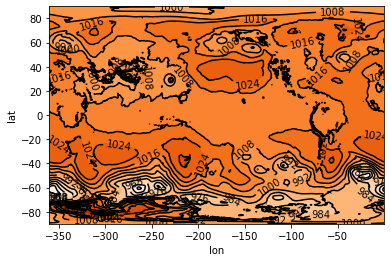

In [19]:
cmap = plt.cm.Oranges      
cf = plt.contourf(lon,lat,press_var,15,cmap = cmap)
cl = plt.contour(lon,lat,press_var,15,colors='black')
plt.clabel(cl,fmt='%.0f',inline=True)
plt.xlabel('lon')
plt.ylabel('lat')
plt.show()

The data looks reasonable enough, so we can proceed to map plotting!

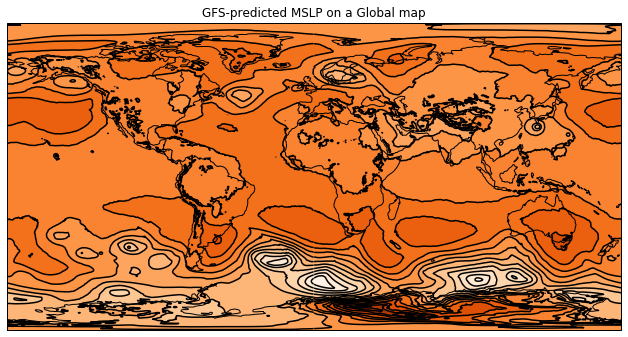

In [20]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_title("GFS-predicted MSLP on a Global map");
ax.coastlines()
cf = plt.contourf(lon,lat,press_var,15,cmap = cmap,transform=ccrs.PlateCarree())
cl = plt.contour(lon,lat,press_var,15,colors='black',transform=ccrs.PlateCarree())


## Cyclic boundaries

This plot looks pretty good right? *Except theres a line straight down the middle of our plot.* What is going on here?<br><br>
Many global data sets, like the GFS model, contain longitude values that go up to, but does not include 360 degrees. Thus, these leaves an artificial gap in the data, usually at the Prime Meridian. Yuck. <br><br>
<b>Good news</b>, we can correct this by using cartopy's `add_cyclic_point` function, which adds at a point at 360, which corresponds to the value at 0 degrees longitude. This is done for both the x coordinate (longitude) and the data (MSLP in this case).<br><br>
Lets try plotting our map again, this time using the `add_cyclic_point` to remove the gap.

In [21]:
from cartopy.util import add_cyclic_point

#Add cyclic to all our variables (MLSP,geopotential height, vorticity, and u and v-winds.
press_varc,lonc = add_cyclic_point(press_var,coord=lon)
gphgt_varc,lonc = add_cyclic_point(gphgt_var,coord=lon)
avort_varc,lonc = add_cyclic_point(avort_var,coord=lon)
uwind_varc,lonc = add_cyclic_point(uwind_var,coord=lon)
vwind_varc,lonc = add_cyclic_point(vwind_var,coord=lon)
rainr_varc,lonc = add_cyclic_point(rainr_var,coord=lon)

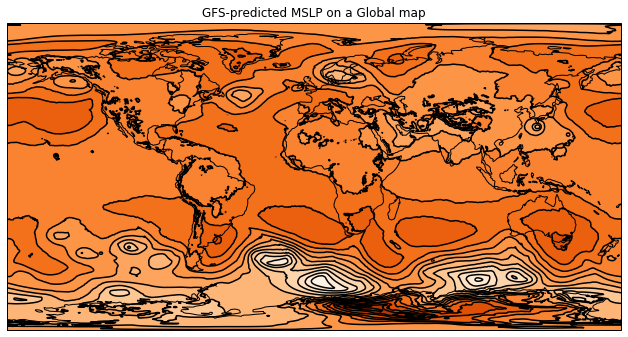

In [22]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_title("GFS-predicted MSLP on a Global map");
ax.coastlines()
cf = plt.contourf(lonc,lat,press_varc,15,cmap = cmap,transform=ccrs.PlateCarree())
cl = plt.contour(lonc,lat,press_varc,15,colors='black',transform=ccrs.PlateCarree())

And now we removed our artificial data gap.<br><br>
Lets zoom in on a region now.

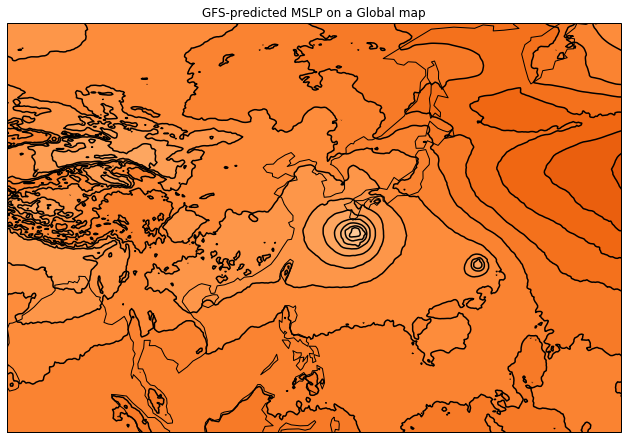

In [23]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([80, 170, 0, 60], crs=projPC)
ax.set_title("GFS-predicted MSLP on a Global map");
ax.coastlines()
cf = plt.contourf(lonc,lat,press_varc,30,cmap = cmap,transform=ccrs.PlateCarree())
cl = plt.contour(lonc,lat,press_varc,30,colors='black',transform=ccrs.PlateCarree())

The map above is a little busy, lets get rid of color filled contour, and color the land tan to be able to differentiate land from ocean easier.

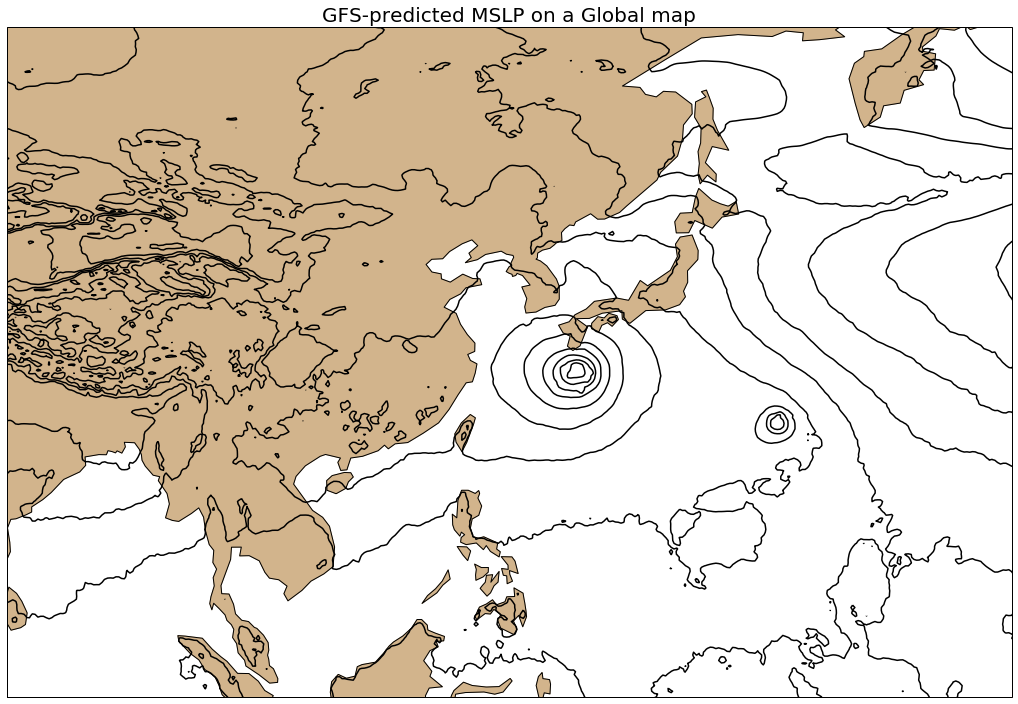

In [24]:
fig = plt.figure(figsize=(18, 14))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([80, 170, 0, 60], crs=projPC)
ax.set_title("GFS-predicted MSLP on a Global map",fontsize = 20);
ax.coastlines()
ax.add_feature(cfeature.LAND,color='tan')
cl = plt.contour(lonc,lat,press_varc,30,colors='black',transform=ccrs.PlateCarree())

Lets overlay some wind barbs to this to help give us a better of what we are looking at...

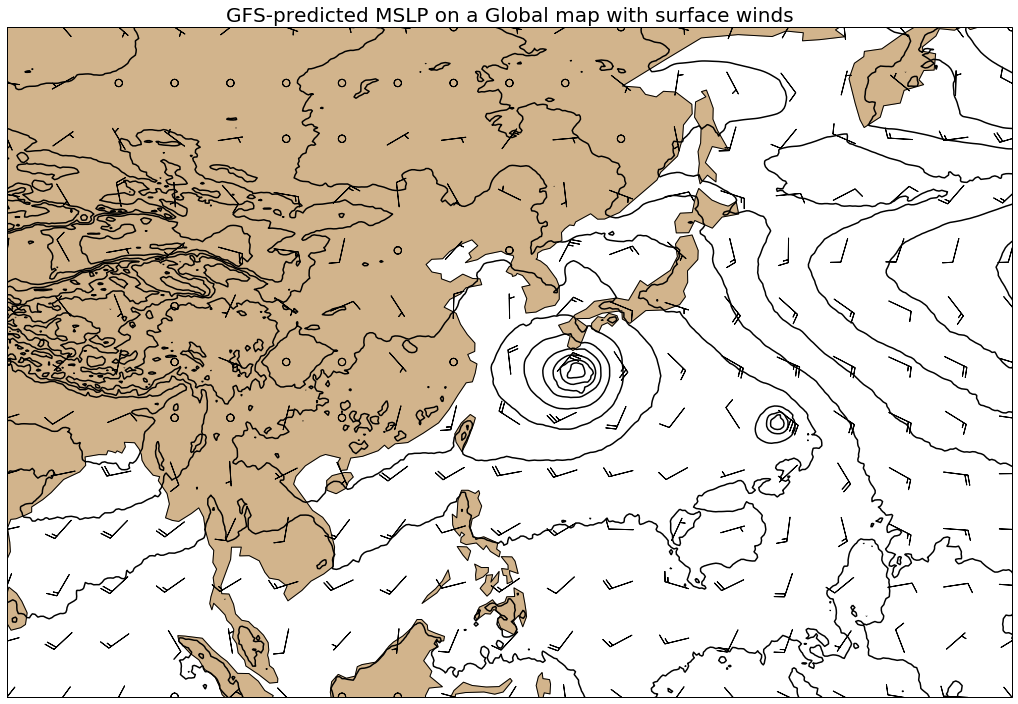

In [25]:
fig = plt.figure(figsize=(18, 14))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([80, 170, 0, 60], crs=projPC)
ax.set_title("GFS-predicted MSLP on a Global map with surface winds",fontsize = 20);
ax.coastlines()
ax.add_feature(cfeature.LAND,color='tan')
cl = plt.contour(lonc,lat,press_varc,30,colors='black',transform=ccrs.PlateCarree())
bw = plt.barbs(lonc[::20],lat[::20],uwind_varc[::20,::20],vwind_varc[::20,::20],pivot='middle')

Lets overlay rain while we are at it too

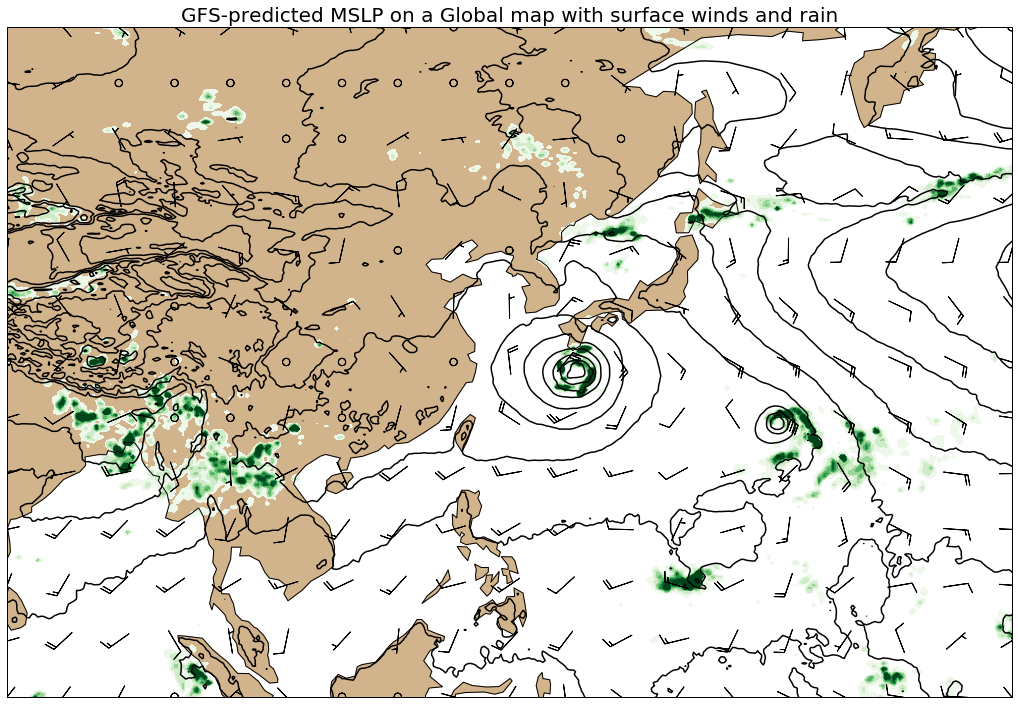

In [26]:
cmap2 = plt.cm.Greens
rainlevels = np.array([0.1,.5,1,1.5,2,2.5,3])*1e-4

fig = plt.figure(figsize=(18, 14))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([80, 170, 0, 60], crs=projPC)
ax.set_title("GFS-predicted MSLP on a Global map with surface winds and rain",fontsize = 20);
ax.coastlines()
ax.add_feature(cfeature.LAND,color='tan')
cl = plt.contour(lonc,lat,press_varc,30,colors='black',transform=ccrs.PlateCarree())
cf = plt.contourf(lonc,lat,rainr_varc,rainlevels,cmap=cmap2,transform=ccrs.PlateCarree(),extend ='max')
bw = plt.barbs(lonc[::20],lat[::20],uwind_varc[::20,::20],vwind_varc[::20,::20],pivot='middle')


<br>

# Do it yourself! #1

Using the examples above, students are encouraged to create their own plots of GFS model data. For your plots, try plotting up a different variable for a different region. Other variables we haven't tried plotting are geopotential heights (good for showing where ridges and troughs are located), precipitable water (amount of water in a column of the atmopshere), vorticity (good for determining location of a weather disturbance), and 2-m temperature.
<br><br>


## Plotting data with irregular grid spacing

A lot of times, environmental science data sets have irregular grid spacings, such that the grid that the data is on is not on a standard lat/lon projection. For example, the HRRR-smoke model is on a Lambert conformal conic projection where the grid cells will have a unique lat/lon value. For example:
<br>
<br>
<img src='../images/HRRR-domain.jpg' width=800px align='center' style='padding-left:50px'>
<br>
<br>
Thankfully, cartopy can seamlessly handle these projections. Instead of the lat/lons being a 1-D vector, the lat/lons need to be provided as a python meshgrid. The next example provides an example of how to display a data set on a irregular grid.

In [27]:
import xarray as xr
import numpy as np
from datetime import datetime,timedelta

#Open up our grib file using xarray, using pynio as an engine
grib_path = "/uufs/chpc.utah.edu/common/home/u0703457/lin-group18/dvm/projects/atmos5340_files/data/hrrr/hrrr.20210805/"
grib_data = xr.open_dataset(grib_path+"hrrr.t00z.wrfsfcf00.grib2", engine="pynio")
smoke_var = grib_data.get("MASSDEN_P0_L103_GLC0")

#Determine the timestamp of the forecast run we are looking at.
forecast_i = str(smoke_var.attrs['initial_time'])
forecast_t = int(smoke_var.attrs['forecast_time'])
timestamp = str(datetime.strptime(forecast_i, '%m/%d/%Y (%H:%M)')+timedelta(hours=forecast_t))

print(smoke_var)

#Read in the variables
lat = np.array(grib_data.coords['gridlat_0'])
lon = np.array(grib_data.coords['gridlon_0'])
smoke_var = np.array(smoke_var)


<xarray.DataArray 'MASSDEN_P0_L103_GLC0' (ygrid_0: 1059, xgrid_0: 1799)>
[1905141 values with dtype=float32]
Coordinates:
    gridlat_0  (ygrid_0, xgrid_0) float32 ...
    gridlon_0  (ygrid_0, xgrid_0) float32 ...
Dimensions without coordinates: ygrid_0, xgrid_0
Attributes:
    center:                                         US National Weather Servi...
    production_status:                              Operational products
    long_name:                                      Mass density (concentration)
    units:                                          kg m-3
    grid_type:                                      Lambert Conformal can be ...
    parameter_discipline_and_category:              Meteorological products, ...
    parameter_template_discipline_category_number:  [ 0  0 20  0]
    level_type:                                     Specified height level ab...
    level:                                          [8.]
    forecast_time:                                  [0]
    forec

Lets check out those lat/lons we read in...

In [28]:
print('lat shape')
print(np.shape(lat))
print('lon shape')
print(np.shape(lon))
print('smoke array shape')
print(np.shape(smoke_var))
print(lat[0:5,0:5])
print(lon[0:5,0:5])

lat shape
(1059, 1799)
lon shape
(1059, 1799)
smoke array shape
(1059, 1799)
[[21.138123 21.14511  21.15209  21.159063 21.166029]
 [21.162994 21.169985 21.176968 21.183943 21.190912]
 [21.187868 21.194862 21.201847 21.208826 21.215797]
 [21.212746 21.21974  21.22673  21.233711 21.240686]
 [21.237623 21.244623 21.251614 21.258598 21.265575]]
[[-122.71953  -122.69286  -122.66619  -122.63952  -122.61284 ]
 [-122.72703  -122.70035  -122.673676 -122.64699  -122.6203  ]
 [-122.73453  -122.70785  -122.68116  -122.65447  -122.62778 ]
 [-122.742035 -122.71535  -122.68865  -122.66196  -122.635254]
 [-122.74954  -122.72285  -122.696144 -122.66944  -122.64274 ]]


Ok, now lets plot up our smoke...

0

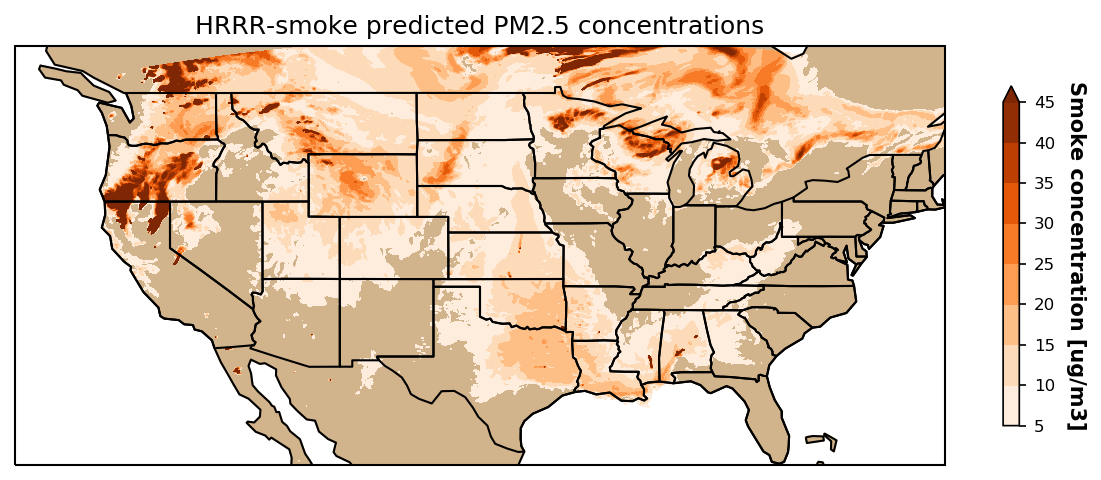

In [29]:
fig = plt.figure(figsize=(10, 10),dpi=150)
cmap = plt.cm.Oranges
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-130, -70, 25, 52], crs=ccrs.PlateCarree())
ax.set_title("HRRR-smoke predicted PM2.5 concentrations",fontsize = 12);
ax.coastlines()
ax.add_feature(cfeature.LAND,color='tan')
ax.add_feature(cfeature.STATES)

smoke_contour = plt.contourf(lon,lat,smoke_var,[5,10,15,20,25,30,35,40,45],cmap = cmap,extend='max',transform=ccrs.PlateCarree())

cbar = plt.colorbar(smoke_contour,ax=ax, shrink=.3,aspect=20)
cbar.set_label('Smoke concentration [ug/m3]', rotation=270,weight='bold',size=10,labelpad=15)
cbar.ax.tick_params(labelsize=8)
plt.savefig('HRRR_smoke_forecast.png')
os.system('mogrify -trim HRRR_smoke_forecast.png HRRR_smoke_forecast.png')

<br>

# Do it yourself! #2

Lets read in an alternative smoke data set from `/uufs/chpc.utah.edu/common/home/u0703457/lin-group7/dvm/projects/atmos5340_files/data/wrfout_smoke_2020-08-20.nc`. This file is in a netcdf format. 

There are a number of variables that students can access including PM2.5, O3 (ozone), CO (carbon monoxide), 2-temp (2 meter temperature), and ground height. *This exercise is meant to be exploratory*, so it will be up to you to decide how you want to plot this data on a map, and to figure out the map projections, dimensions, and so on. As you start sleuthing through the data set, you will notice there are multiple times, and so I encourage everyone to create an image for each time that is available in this data set. It would also be good to print the time on the figure title.

Show me what you end up coming up with!

<br><br>

# Want more practice!?

Check out the following webpages:<br>
https://scitools.org.uk/cartopy/docs/v0.15/matplotlib/intro.html<br>
https://foundations.projectpythia.org/core/cartopy/cartopy.html<br>
https://scitools.org.uk/cartopy/docs/v0.15/matplotlib/advanced_plotting.html<br>
https://spire.com/tutorial/spire-weather-tutorial-intro-to-processing-grib2-data-with-python/<br>
https://uoftcoders.github.io/studyGroup/lessons/python/cartography/lesson/<br>
https://docs.xarray.dev/en/stable/<br>


    